# WebSky Analysis

## CMB + tSZ + noise

In [1]:
### IMPORTS ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
from scipy.interpolate import *
import matplotlib.pyplot as plt

In [2]:
### cosmology.py ###

omegab = 0.049
omegac = 0.261
omegam = omegab + omegac
h      = 0.68
ns     = 0.965
sigma8 = 0.81

c = 3e5

H0 = 100*h
nz = 100000
z1 = 0.0
z2 = 6.0
za = np.linspace(z1,z2,nz)
dz = za[1]-za[0]

H      = lambda z: H0*np.sqrt(omegam*(1+z)**3+1-omegam)
dchidz = lambda z: c/H(z)

chia = np.cumsum(dchidz(za))*dz

zofchi = interp1d(chia,za)

print("Cosmology set up with:")
print(f"omegab = {omegab}")
print(f"omegac = {omegac}")
print(f"omegam = {omegam}")
print(f"h = {h}")
print(f"ns = {ns}")
print(f"sigma8 = {sigma8}")

Cosmology set up with:
omegab = 0.049
omegac = 0.261
omegam = 0.31
h = 0.68
ns = 0.965
sigma8 = 0.81


## PIPELINE

In [ ]:
### 1. Load WebSky Components --- https://lambda.gsfc.nasa.gov/simulation/mocks_data.html --- tSZ & CMB in muK units ###

# These are usually at high resolution (Nside 4096). 
# You might need to downgrade them to Nside 128 or 256 for faster testing.
path_to_websky = '/Users/joanribot/HEAVY_STUFF/WebSky_CMB_Mocks/'

# Set your working resolution and corresponding lmax
nside_work = 2048

# A. Load tSZ and downgrade
y_map_raw = hp.read_map(path_to_websky + "tsz.fits")
y_map = hp.ud_grade(y_map_raw, nside_out=nside_work)

# B. Load CMB alms and let it detect the original Lmax ######### CHECK UNITS FOR CMB TOO
# Use return_mmax=True to be extra safe with WebSky's format
alms_cmb, mmax_in = hp.read_alm(path_to_websky + "unlensed_alm.fits", hdu=1, return_mmax=True)

# C. Calculate the Lmax of the file data
lmax_in = hp.Alm.getlmax(len(alms_cmb), mmax_in)

# D. Convert to map. 
# We tell it the ALMs are at 'lmax_in', but we want the result at 'nside_work'
cmb_map = hp.alm2map(alms_cmb, nside=nside_work, lmax=lmax_in, mmax=mmax_in)

In [12]:
### 2. Define the tSZ frequency scaling function and Taylor expansion ###

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    T_cmb = 2.7255 # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency

    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4

    #g_nu_T_CMB = g_nu * T_cmb # IF DATA IN MU_K, CONVERT TO K

    return g_nu

def get_tsz_f(nu):
    """Calculate the tSZ frequency scaling f(nu) in dimensionless units."""
    T_cmb = 2.7255 # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency

    f_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: f_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #f_nu = (-x/2) * (1 / np.sinh(x/2)**2)

    #f_nu_T_CMB = f_nu * T_cmb # IF DATA IN MU_K, CONVERT TO K

    return f_nu

In [ ]:
### 3. Define the noise frequency dependent map function --- SHOULD I ADD THE UK UNITS HERE? ###

def get_noise_map(nside, sensitivity_uk_arcmin):
    """
    Calculates white noise per pixel based on instrument sensitivity.
    """
    npix = hp.nside2npix(nside)
    # Convert arcmin^2 to steradians - pixel_area in steradians = (pi/180/60)^2 * sensitivity^2
    # But healpy has a direct tool:
    pixel_area_arcmin2 = hp.nside2pixarea(nside, degrees=True) * 3600
    
    # Noise sigma per pixel
    sigma_pixel = sensitivity_uk_arcmin / np.sqrt(pixel_area_arcmin2)
    
    return np.random.normal(0, sigma_pixel, npix)

In [8]:
### 4. Create the 'Data Cube' at different frequencies ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

frequencies = [30, 44, 70, 70, 100, 143, 217, 353, 545, 857] # GHz --- kickoff diapo. 8
#planck_frequencies = [143, 217, 353, 545, 857]
#component_frequencies = [40, 60, 100, 140, 166, 195, 280, 337, 402] # GHz --- kickoff diapo. 9

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Reference noise
base_sensitivity_uk_arcmin = 30.0

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier

    print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    
    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK
    
    # Noise realization (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise
    total_map = cmb_map + signal_tsz + noise_map
    data_cube.append(total_map)

data_cube = np.array(data_cube)

# Now 'data_cube' is ready for your ILC functions!

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30 GHz, Noise per pixel: 17.46 uK
Frequency: 44 GHz, Noise per pixel: 20.96 uK
Frequency: 70 GHz, Noise per pixel: 24.45 uK
Frequency: 70 GHz, Noise per pixel: 27.94 uK
Frequency: 100 GHz, Noise per pixel: 31.44 uK
Frequency: 143 GHz, Noise per pixel: 34.93 uK
Frequency: 217 GHz, Noise per pixel: 38.42 uK
Frequency: 353 GHz, Noise per pixel: 41.92 uK
Frequency: 545 GHz, Noise per pixel: 45.41 uK
Frequency: 857 GHz, Noise per pixel: 48.90 uK


In [ ]:
### OLD DATA CUBE - IGNORE ###

### 4. Create the 'Data Cube' at different frequencies ###

data_cube = []
noise_std_dev = 2.0 / 27.5 # Example constant sigma, but zero mean!
frequencies = [30, 44, 70, 70, 100, 143, 217, 353, 545, 857] # GHz --- kickoff diapo. 8
#planck_frequencies = [143, 217, 353, 545, 857]
#component_frequencies = [40, 60, 100, 140, 166, 195, 280, 337, 402] # GHz --- kickoff diapo. 9
T_cmb_muK = 2.7255e6 # Conversion factor for Compton-y to muK


# New data_cube with different noise for each frequency channel
for i, nu in enumerate(frequencies):
    g_nu = get_tsz_g(nu)
    
    # Correct Signal for THIS frequency
    signal_tsz = g_nu * y_map * T_cmb_muK
    
    # Correct Noise: Mean=0, Sigma=calculated. Independent for each i.
    noise = np.random.normal(0, noise_std_dev, len(cmb_map))
    noise_layer = get_noise_map(nside_work, 30.0)  # You can vary this for different frequencies if you want
    
    # Total = CMB (const) + tSZ (scaled) + Noise
    total_map = cmb_map + signal_tsz + noise
    data_cube.append(total_map)

# Convert to array for ILC: shape (n_freq, n_pix)
data_cube = np.array(data_cube)

# Now 'data_cube' is ready for your ILC functions!

In [9]:
len(cmb_map)

50331648

## ILC

### METHOD DEFINITION

In [13]:
def run_pixel_ilc(data_cube, g_vector):
    """Supervisor's requested Pixel-Space ILC"""
    n_freq, n_pix = data_cube.shape
    C = (1.0 / n_pix) * (data_cube @ data_cube.T)
    C_inv = np.linalg.pinv(C)
    
    weights = (C_inv @ g_vector) / (g_vector.T @ C_inv @ g_vector)
    return weights @ data_cube, weights

In [14]:
def run_harmonic_ilc_with_weights(data_cube, g_vector, l_bins):
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    # NEW: Matrix to store weights for each bin
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)
        
        # Calculate weights for THIS specific scale
        w_bin = (inv_cov @ g_vector) / (g_vector.T @ inv_cov @ g_vector)
        weights_per_bin.append(w_bin) # Store them
        
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside), np.array(weights_per_bin)

### ILC PROCESSING AND COMPARISON

In [17]:
### EXECUTE BOTH METHODS ###

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Define g_vector and f_vector in muK units for the frequencies in the data cube
g_vector_muK = np.array([get_tsz_g(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K
f_vector_muK = np.array([get_tsz_f(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

### Pixel ILC ###
y_hat_pixel_muK, weights_pixel = run_pixel_ilc(data_cube, g_vector_muK)

# Convert y_map to muK units for comparison
y_map_muK = y_map * T_cmb_muK

# Residual map in muK units for pixel ILC
residual_pixel = y_map_muK - y_hat_pixel_muK



### Harmonic ILC (with weights) ###
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 1000]

# Calculate the harmonic ILC reconstruction and get the weights for each bin
y_hat_harmonic_muK, weights_harmonic_bins = run_harmonic_ilc_with_weights(data_cube, g_vector_muK, l_bins)

# Residual map in muK units for harmonic ILC
residual_harmonic = y_map_muK - y_hat_harmonic_muK

In [19]:
print(g_vector_muK)

[-5.32482325e+06 -5.18100961e+06 -4.77771592e+06 -4.77771592e+06
 -4.11032770e+06 -2.83551138e+06 -2.11910750e+04  6.10714400e+06
  1.52574296e+07  3.02275361e+07]


In [29]:
### ILC ANALYSIS WEIGHTS FOR PIXEL_ILC ###

#g_vector = np.array([get_tsz_g(nu) for nu in frequencies])
#y_hat_muK, weights_pixel_ilc = run_pixel_ilc(data_cube, g_vector)

df_weights_pixel_ilc = pd.DataFrame({
    'Freq (GHz)': frequencies,
    #'Weight': weights_pixel_ilc
    'Weight': weights_pixel,
    'g(nu) * T_cmb_muK': g_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_ilc = df_weights_pixel_ilc.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("--- ILC Analysis Weights ---")
print(df_horizontal_pixel_ilc)
print()

# Verify the constraint is satisfied
constraint_check_pixel_ilc = np.sum(weights_pixel * g_vector_muK)
weights_pixel_sum = np.sum(weights_pixel)
print(f"Constraint Check: {constraint_check_pixel_ilc:.4f}")
print(f"Sum of Weights: {weights_pixel_sum:.4f}")
print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

--- ILC Analysis Weights ---
Freq (GHz)                  30            44            70            70            100           143           217           353           545           857
Weight            -1.497588e-08 -9.930917e-09 -6.364963e-09 -4.876153e-09 -2.889907e-09 -8.537141e-10  1.989233e-09  6.599162e-09  1.192160e-08  1.914297e-08
g(nu) * T_cmb_muK -5.324823e+06 -5.181010e+06 -4.777716e+06 -4.777716e+06 -4.110328e+06 -2.835511e+06 -2.119107e+04  6.107144e+06  1.525743e+07  3.022754e+07

Constraint Check: 1.0000
Sum of Weights: -0.0000
Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.


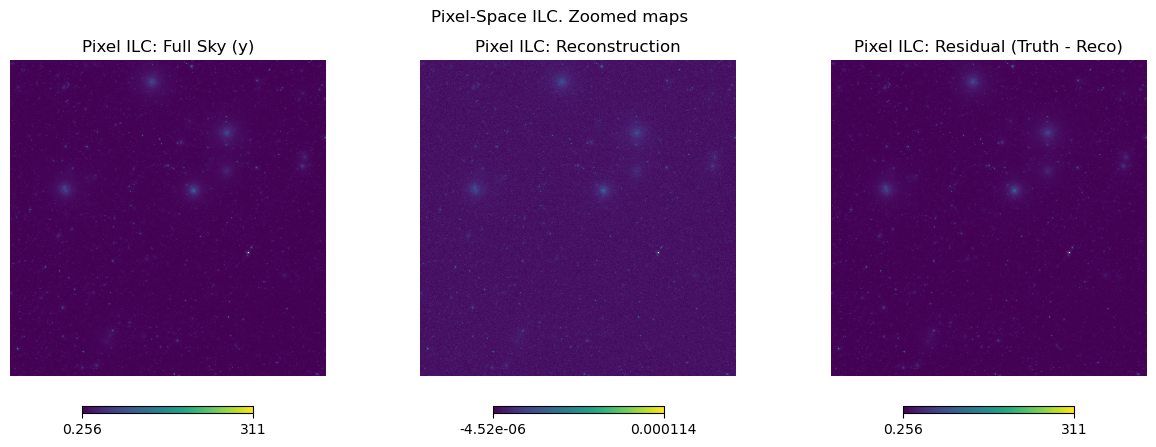

In [41]:
### A.1. PIXEL ILC ZOOMED MAPS ###

# Define units: use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$" ### WE ARE NOT USING THEM THO!!!

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -10**-5, 'max': 10**-5}
params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 600, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
hp.gnomview(y_map_muK, title="Pixel ILC: Full Sky (y)", **params_zoom)
plt.subplot(1, 3, 2)
hp.gnomview(y_hat_pixel_muK, title="Pixel ILC: Reconstruction", **params_zoom)
plt.subplot(1, 3, 3)
hp.gnomview(residual_pixel, title="Pixel ILC: Residual (Truth - Reco)", **params_zoom)

plt.suptitle("Pixel-Space ILC. Zoomed maps")
plt.show()

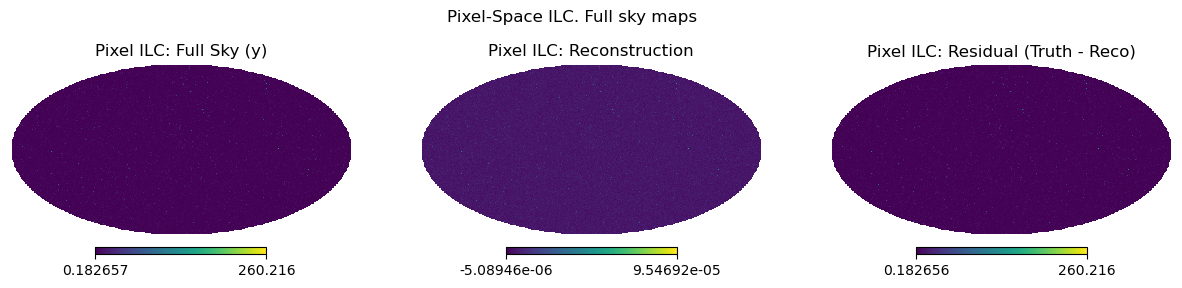

In [40]:
### A.2. PIXEL ILC FULL SKY MAPS ###

params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -10**-5, 'max': 10**-5}
params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
hp.mollview(y_map_muK, title="Pixel ILC: Full Sky (y)", **params_moll)
plt.subplot(1, 3, 2)
hp.mollview(y_hat_pixel_muK, title="Pixel ILC: Reconstruction", **params_moll)
plt.subplot(1, 3, 3)
hp.mollview(residual_pixel, title="Pixel ILC: Residual (Truth - Reco)", **params_moll)

plt.suptitle("Pixel-Space ILC. Full sky maps")
plt.show()

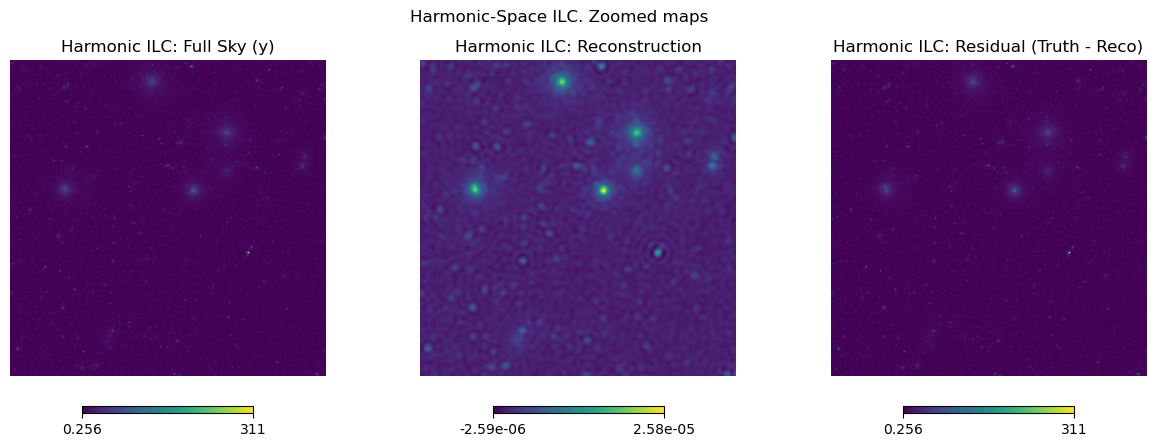

In [ ]:
### B.1. HARMONIC ILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -10**-5, 'max': 10**-5}
params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 600, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
hp.gnomview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_zoom)
plt.subplot(1, 3, 2)
hp.gnomview(y_hat_harmonic_muK, title="Harmonic ILC: Reconstruction", **params_zoom)
plt.subplot(1, 3, 3)
hp.gnomview(residual_harmonic, title="Harmonic ILC: Residual (Truth - Reco)", **params_zoom)

plt.suptitle("Harmonic-Space ILC. Zoomed maps")
plt.show()

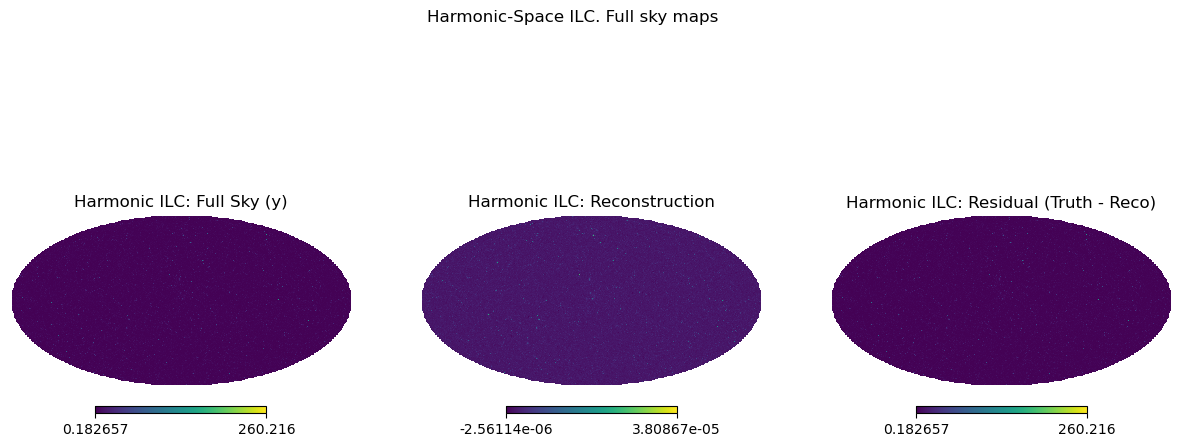

In [45]:
### B.2. HARMONIC ILC FULL SKY MAPS ###

params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -10**-5, 'max': 10**-5}
params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
hp.mollview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_moll)
plt.subplot(1, 3, 2)
hp.mollview(y_hat_harmonic_muK, title="Harmonic ILC: Reconstruction", **params_moll)
plt.subplot(1, 3, 3)
hp.mollview(residual_harmonic, title="Harmonic ILC: Residual (Truth - Reco)", **params_moll)

plt.suptitle("Harmonic-Space ILC. Full sky maps")
plt.show()

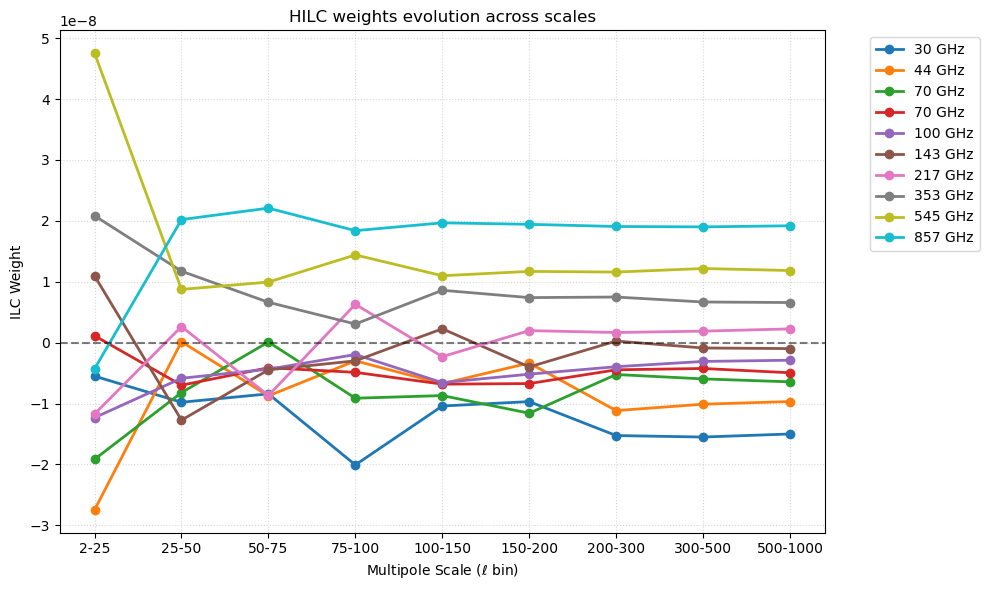

In [46]:
### B.3. HARMONIC WEIGHTS EVOLUTION ###

plt.figure(figsize=(10, 6))

# Define labels for the x-axis bins
bin_labels = [f"{l_bins[i]}-{l_bins[i+1]}" for i in range(len(l_bins)-1)]

for f_idx, nu in enumerate(frequencies):
    plt.plot(bin_labels, weights_harmonic_bins[:, f_idx], label=f"{nu} GHz", marker='o', linewidth=2)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(rf"Multipole Scale ($\ell$ bin)")
plt.ylabel("ILC Weight")
plt.title("HILC weights evolution across scales")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
### ZOOMED VISUALIZATION OF INDIVIDUAL COMPONENTS ###

# 1. Choose the frequency to inspect
# Index 0 is 30 GHz in frequencies = [30, 44, 70, 70, 100, 143, 217, 353, 545, 857]
nu_idx = 0
nu_val = frequencies[nu_idx]

# 2. Calculate proper Scaling and Constants
g_nu = get_tsz_g(nu_val)
T_cmb_muK = 2.7255e6 

# 3. Calculate the proper Noise Sigma for this channel
# Using the Nside-dependent scaling and the frequency multiplier
base_noise_128 = 2.0
nside_scaling = nside_work / 128.0
freq_noise_multiplier = 1.0 + (nu_idx * 0.2)
current_sigma = base_noise_128 * nside_scaling * freq_noise_multiplier

# 4. Generate the Layers
# Layer A: Primary CMB (loaded from WebSky)
# Layer B: tSZ Signal
signal_tsz = g_nu * y_map * T_cmb_muK
# Layer C: Proper Noise (Zero-mean, proper sigma)
noise_layer = np.random.normal(0, current_sigma, len(cmb_map))
# Layer D: Total Map
total_map = cmb_map + signal_tsz + noise_layer

# 5. Plotting (2x2 Grid)
fig = plt.figure(figsize=(16, 12))
# reso: for Nside 1024, 1.5 arcmin per pixel is good. 
# rot: center on [0,0] or a specific cluster
params = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -100, 'max': 100} # 'min': -200, 'max': 200 --- FOR COMPARING THE INTENSITY OF THE COMPONENTS WITH THE SAME COLOR SCALE (uK)


# Use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

# --- Plotting ---

# Subplot 1: The CMB
plt.subplot(2, 2, 1)
hp.gnomview(cmb_map, title="1. Primary CMB", unit=unit_label, **params)

# Subplot 2: The tSZ Signal (Changes with frequency)
plt.subplot(2, 2, 2)
hp.gnomview(signal_tsz, title=rf"2. tSZ Signal ({nu_val} GHz)", unit=unit_label, **params)

# Subplot 3: Proper Instrumental Noise
plt.subplot(2, 2, 3)
hp.gnomview(noise_layer, title="3. Instrumental Noise", unit=unit_label, **params)

# Subplot 4: The Total Map (What the telescope sees)
plt.subplot(2, 2, 4)
hp.gnomview(total_map, title=rf"4. TOTAL Observed ({nu_val} GHz)", unit=unit_label, **params)

plt.suptitle(f"Frequency Channel Breakdown: {nu_val} GHz", fontsize=18, y=0.95)
plt.show()

In [ ]:
### MOLLWEIDE VIEW OF INDIVIDUAL COMPONENTS ###

# 1. Choose the frequency to inspect
# Index 0 is 30 GHz in frequencies = [30, 44, 70, 70, 100, 143, 217, 353, 545, 857]
nu_idx = 9
nu_val = frequencies[nu_idx]

# 2. Calculate proper Scaling and Constants
g_nu = get_tsz_g(nu_val)
T_cmb_muK = 2.7255e6 

# 3. Calculate the proper Noise Sigma for this channel
# Using the Nside-dependent scaling and the frequency multiplier
base_noise_128 = 2.0
nside_scaling = nside_work / 128.0
freq_noise_multiplier = 1.0 + (nu_idx * 0.2)
current_sigma = base_noise_128 * nside_scaling * freq_noise_multiplier

# 4. Generate the Layers
# Layer A: Primary CMB (loaded from WebSky)
# Layer B: tSZ Signal
signal_tsz = g_nu * y_map * T_cmb_muK
# Layer C: Proper Noise (Zero-mean, proper sigma)
noise_layer = np.random.normal(0, current_sigma, len(cmb_map))
# Layer D: Total Map
total_map = cmb_map + signal_tsz + noise_layer

# 5. Plotting (2x2 Grid)
fig = plt.figure(figsize=(16, 12))
# reso: for Nside 1024, 1.5 arcmin per pixel is good. 
# rot: center on [0,0] or a specific cluster
params = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -100, 'max': 100} # 'min': -200, 'max': 200 --- FOR COMPARING THE INTENSITY OF THE COMPONENTS WITH THE SAME COLOR SCALE (uK)


# Use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

# --- Plotting ---

# Subplot 1: The CMB
plt.subplot(2, 2, 1)
hp.mollview(cmb_map, title="1. Primary CMB", unit=unit_label, **params)

# Subplot 2: The tSZ Signal (Changes with frequency)
plt.subplot(2, 2, 2)
hp.mollview(signal_tsz, title=rf"2. tSZ Signal ({nu_val} GHz)", unit=unit_label, **params)

# Subplot 3: Proper Instrumental Noise
plt.subplot(2, 2, 3)
hp.mollview(noise_layer, title="3. Instrumental Noise", unit=unit_label, **params)

# Subplot 4: The Total Map (What the telescope sees)
plt.subplot(2, 2, 4)
hp.mollview(total_map, title=rf"4. TOTAL Observed ({nu_val} GHz)", unit=unit_label, **params)

plt.suptitle(f"Frequency Channel Breakdown: {nu_val} GHz", fontsize=18, y=0.95)
plt.show()

### FULL DATA AT ALL FREQUENCIES

In [ ]:
### MULTI-FREQUENCY GNOMVIEW ###

fig = plt.figure(figsize=(22, 10))
unit_label = r"$\mu K_{CMB}$"

# Shared parameters for all zooms
params_gnom = {
    'rot': [0, 0], 
    'reso': 1.5, 
    'xsize': 400, 
    'hold': True, 
    'cmap': 'viridis',
    'notext': True,  # Removes lat/lon
    'cbar': False,   # We will add a single shared colorbar later or small ones manually
    'min': -250, 
    'max': 250
}

for i, nu in enumerate(frequencies):
    # Data generation
    g_nu = get_tsz_g(nu)
    signal_tsz = g_nu * y_map * T_cmb_muK
    current_sigma = base_noise_128 * nside_scaling * (1.0 + (i * 0.2))
    noise_layer = np.random.normal(0, current_sigma, len(cmb_map))
    total_map = cmb_map + signal_tsz + noise_layer
    
    # Create subplot
    ax = fig.add_subplot(2, 5, i+1)
    
    # Plot map
    hp.gnomview(total_map, **params_gnom)
    
    # Add title manually with matplotlib for better spacing
    plt.title(f"{nu} GHz", fontsize=16, pad=10)

# Add a single colorbar at the bottom for the whole figure
# [left, bottom, width, height]
cax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=-250, vmax=250))
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label(unit_label, fontsize=14)

plt.suptitle("Total Observed Signals (Zoomed) - Frequency Evolution", fontsize=22, y=1.02)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

In [ ]:
### MULTI-FREQUENCY MOLLVIEW ###

fig = plt.figure(figsize=(22, 10))
unit_label = r"$\mu K_{CMB}$"

# Shared parameters for all zooms

params_moll = {
    'hold': True, 
    'cmap': 'viridis',
    'notext': True,
    'cbar': False, # Turn off auto-colorbar to prevent overlapping
    'min': -300, 
    'max': 300
}

for i, nu in enumerate(frequencies):
    # Data generation
    g_nu = get_tsz_g(nu)
    signal_tsz = g_nu * y_map * T_cmb_muK
    current_sigma = base_noise_128 * nside_scaling * (1.0 + (i * 0.2))
    noise_layer = np.random.normal(0, current_sigma, len(cmb_map))
    total_map = cmb_map + signal_tsz + noise_layer
    
    # Create subplot
    ax = fig.add_subplot(3, 4, i+1)
    
    # Plot map
    hp.mollview(total_map, **params_moll)
    
    # Add title manually with matplotlib for better spacing
    plt.title(f"{nu} GHz", fontsize=16, pad=10)

# Add a single colorbar at the bottom for the whole figure
# [left, bottom, width, height]
cax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=-250, vmax=250))
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label(unit_label, fontsize=14)

plt.suptitle("Total Observed Signals (Zoomed) - Frequency Evolution", fontsize=22, y=1.02)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

In [ ]:
### USAGE EXAMPLE OF ILC FUNCTIONS ON WEBSKY DATA AND VISUALIZATION ###

# -------------------------------------------------------------------------
# EXECUTE ILC ON WEBSKY DATA
# -------------------------------------------------------------------------

# Calculate the g-vector for the specific frequencies you used in the cube
# Assuming frequencies = [143, 217, 353, 545, 857]
g_vector = np.array([get_tsz_g(nu) for nu in frequencies])

# A. Run Pixel-Space ILC
y_hat_pixel_muK, weights_pixel = run_pixel_ilc(data_cube, g_vector)

# B. Run Harmonic-Space ILC (Lmax should be roughly 3*Nside)
lbins = [2, 100, 300, 1000] # Example bins for multi-scale ILC
y_hat_harmonic_muK = run_harmonic_ilc_with_weights(data_cube, g_vector, lbins)

# Convert results back to dimensionless Compton-y to compare with y_map
T_cmb_muK = 2.7255e6
y_reconstructed_pixel = y_hat_pixel_muK / T_cmb_muK
y_reconstructed_harmonic = y_hat_harmonic_muK / T_cmb_muK

# -------------------------------------------------------------------------
# VISUALIZE PERFORMANCE
# -------------------------------------------------------------------------

fig = plt.figure(figsize=(18, 6))
params = {'rot': [0, 0], 'reso': 15, 'xsize': 400, 'hold': True}

# Subplot 1: The "Truth" (The y_map we want to recover)
plt.subplot(1, 3, 1)
hp.gnomview(y_map, title="Target: WebSky tSZ (y)", **params)

# Subplot 2: Result from Pixel ILC
plt.subplot(1, 3, 2)
hp.gnomview(y_reconstructed_pixel, title="Recovered: Pixel ILC", **params)

# Subplot 3: Result from Harmonic ILC
plt.subplot(1, 3, 3)
hp.gnomview(y_reconstructed_harmonic, title="Recovered: Harmonic ILC", **params)

plt.show()

pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print(f"Optimal Weights (Pixel ILC): {weights_pixel}")

In [ ]:
# Let's do the same for the CMB component to see how well we can recover it (though we didn't explicitly target it, it's interesting to check)
# For CMB, the g-vector is just [1, 1, 1, 1, 1] since CMB is constant across frequencies in thermodynamic units
g_vector_cmb = np.ones(len(frequencies))
cmb_reconstructed_pixel = run_pixel_ilc(data_cube, g_vector_cmb)[0]
cmb_reconstructed_harmonic = run_harmonic_ilc_with_weights(data_cube, g_vector_cmb, lbins)

# Calculate residuals for tSZ
residual = y_map - y_reconstructed_pixel
residual_harmonic = y_map - y_reconstructed_harmonic
bias = np.mean(residual)

# And plot the residuals to see where the methods struggle the most. This can highlight if there are specific regions (e.g., around clusters) where one method outperforms the other.
fig = plt.figure(figsize=(18, 6))
params = {'rot': [0, 0], 'reso': 15, 'xsize': 400, 'hold': True}

# Subplot 1: The "Truth" (The y_map we want to recover)
plt.subplot(1, 3, 1)
hp.gnomview(cmb_map, title="Target: WebSky CMB", **params)

# Subplot 2: Result from Pixel ILC
plt.subplot(1, 3, 2)
hp.gnomview(cmb_reconstructed_pixel, title="Recovered: Pixel ILC", **params)

# Subplot 3: Result from Harmonic ILC
plt.subplot(1, 3, 3)
hp.gnomview(cmb_reconstructed_harmonic, title="Recovered: Harmonic ILC", **params)

plt.show()

pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print(f"Optimal Weights (Pixel ILC): {weights_pixel}")

In [ ]:
microK

sqrt 4pi / 12*Nside^2 * 180/pi * 60 i ja ho tenim en arcmin

In [ ]:
print(np.sqrt((4*np.pi)/(12*128**2)) * 180 / np.pi * 60)
print(np.sqrt((4*np.pi)/(12*2048**2)) * 180 / np.pi * 60)

In [ ]:
2/27.48 # això ´és la rms DEL NOISE PER nSIDE 128

In [ ]:
RESIDUALS PER CMB TOO

C localitzat, no mitja global

### Residuals

In [ ]:
### RESIDUAL ANALYSIS - Gemini ###

# Calculate Residual (Truth - Reconstruction)
residual = y_map - y_reconstructed_pixel

residual_harmonic = y_map - y_reconstructed_harmonic

fig = plt.figure(figsize=(15, 6))
params = {'rot': [0, 0], 'reso': 15, 'xsize': 400, 'hold': True}

# Plot the Reconstruction
plt.subplot(1, 2, 1)
hp.gnomview(y_reconstructed_pixel, title="Recovered tSZ (y)", **params)


# Plot the Residual
#plt.subplot(1, 2, 2)
#hp.gnomview(residual, title="Residual (Truth - Recovered)", **params)
#
# Plot the Reconstruction for harminoic
plt.subplot(1, 2, 2)
hp.gnomview(residual_harmonic, title="Recovered tSZ (y) - Harmonic", **params)

plt.show()

# Calculate Numerical Metrics
bias = np.mean(residual)
std_resid = np.std(residual)
print(f"Residual Mean (Bias): {bias:.2e}")
print(f"Residual Std Dev (Noise Level): {std_resid:.2e}")

bias2 = np.mean(residual_harmonic)
std_resid2 = np.std(residual_harmonic)
print(f"Residual Mean (Bias) - Harmonic: {bias2:.2e}")
print(f"Residual Std Dev (Noise Level) - Harmonic: {std_resid2:.2e}")

In [ ]:
### RESIDUAL ANALYSIS - Autocomplete ###

# Compute residuals for each method
residual_pixel = y_map - y_reconstructed_pixel
residual_harmonic = y_map - y_reconstructed_harmonic

# Plot residuals
fig = plt.figure(figsize=(18, 6))
params = {'rot': [0, 0], 'reso': 15, 'xsize': 400, 'hold': True, 'min': -1e-6, 'max': 1e-6}  # Adjust min/max for better contrast

# Subplot 1: Residual from Pixel ILC
plt.subplot(1, 3, 1)
hp.gnomview(residual_pixel, title="Residual: Pixel ILC", **params)

# Subplot 2: Residual from Harmonic ILC
plt.subplot(1, 3, 2)
hp.gnomview(residual_harmonic, title="Residual: Harmonic ILC", **params)

# Subplot 3: Difference between residuals (to see where one is better than the other)
diff_residuals = residual_pixel - residual_harmonic
plt.subplot(1, 3, 3)
hp.gnomview(diff_residuals, title="Difference of Residuals", **params)

plt.show()

PLOT ON THE SAME SCALES FOR BETTER COMPARISON

en una zona localitzada its better the pixel ilc que harmonic, però si fessim només cmb podria ser al revés

monopols l? FEIM L = 0 PER CMB!!!

In [ ]:
# Low monopoles l perform better in harmonic space, but might have more noise at small scales. The difference plot can highlight specific regions where one method outperforms the other.

In [ ]:
### WEIGHTS ANALYSIS ###

# Create a nice table for the weights
df_weights = pd.DataFrame({
    'Frequency (GHz)': frequencies,
    'g_nu (Scaling)': g_vector,
    'ILC Weight': weights_pixel
})

print("--- ILC Analysis Weights ---")
print(df_weights.to_string(index=False))

# Optional: Plot the weights to see which frequency 'contributes' most
df_weights.plot(x='Frequency (GHz)', y='ILC Weight', kind='bar', color='teal')
plt.title("Contribution of each Frequency to the ILC Map")
plt.ylabel("Weight Value")
plt.show()

## Extrapolation of the CIB code

### I think it's wrong, just IGNORE

In [ ]:
### 1. The Standard Full-Sky View (Mollview) ###

# A single example: map at the first frequency (143 GHz)
hp.mollview(data_cube[0], title=f"Data Cube Map: {frequencies[0]} GHz", unit=r"$\mu K$", norm='hist', cmap='viridis', coord=['C','G'])
plt.show()

# A loop to show all frequencies (uncomment if you want to see them all)
#for i, nu in enumerate(frequencies):
#    hp.mollview(data_cube[i], 
#                title=f"Data Cube Map: {nu} GHz", 
#                unit=r"$\mu K$", 
#                norm='hist', # Helps see the CIB/tSZ structures better
#                cmap='viridis',
#                coord=['C','G']) # Show in Galactic coordinates use coord=['C','G']; to do it in Equatorial use coord=['C','E']
#
#    plt.show()

In [ ]:
### 2. Side-by-Side Comparison ###

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

plt.axes(ax1)
hp.mollview(data_cube[0], title=f"{frequencies[0]} GHz", hold=True, unit=r"$\mu K$", norm='hist', cmap='viridis')

plt.axes(ax2)
hp.mollview(data_cube[3], title=f"{frequencies[3]} GHz", hold=True, unit=r"$\mu K$")

plt.show()

In [ ]:
### 3. Comparison for all frequencies ###

fig = plt.figure(figsize=(20, 12))

for i, nu in enumerate(frequencies):
    plt.subplot(2, 3, i+1)
    hp.mollview(data_cube[i], title=f"{nu} GHz", hold=True, unit=r"$\mu K$", cmap='viridis')
    plt.axis('off')
plt.show()

In [ ]:
### 4. Checking that the Data Cube is Correctly Constructed ###

# A quick visual check to see if the "randomness" is the same signal
diff01 = data_cube[1] - data_cube[0]
hp.mollview(diff01, title=f"Difference ({frequencies[4]} - {frequencies[0]})")#, norm='hist')

#diff02 = data_cube[2] - data_cube[0]
#hp.mollview(diff02, title=f"Difference ({frequencies[2]} - {frequencies[0]})", norm='hist')

In [ ]:
### 5. Gnomonic Comparison (Zoom-in) for all ###

fig = plt.figure(figsize=(20, 12))

# Define the view parameters
# rot: [longitude, latitude] in degrees to center the zoom
# reso: resolution in arcmin per pixel (1.5 is standard for Nside 512-ish)
# xsize: width/height of the patch in pixels
view_params = {'rot': [0, 0], 'reso': 10, 'xsize': 200} 

for i, nu in enumerate(frequencies):
    # We create the subplot using matplotlib notation
    ax = fig.add_subplot(2, 3, i+1)
    
    # Use gnomview for the zoom
    # min/max: manually setting these helps compare the brightness across frequencies
    hp.gnomview(data_cube[i], 
                title=f"{nu} GHz", 
                hold=True, 
                unit=r"$\mu K$", 
                cmap='viridis',
                # norm='hist', # Uncomment if you want to see the CIB fluctuations more clearly
                min=-150, max=150, # Adjust these based on your map's actual values
                **view_params)
    
plt.show()

## WebSky model

See https://github.com/simonsobs/websky_model.git for documentation.

In [ ]:
import numpy as np
import websky_model as wm

# load model
wmodel = wm.WebSky(directory_path='/global/project/projectdirs/sobs/v4_sims/mbs/websky/data/',websky_version = 'v0.1', verbose=True)

# read in halo catalogue
hcat  = wmodel.load_halo_catalogue(mmin=0, mmax=np.inf, zmin=0, zmax=np.inf, rmin=0., rmax=np.inf, practical=True)

# project halos onto healpix map. 
# each halo is given a "flux" of weight=constant, or weight=array(len(Nhalo))
hpmap = wmodel.catalogue_to_map(hcat, nside=512, weight=1)

# get cib map filename
fname_cib = wmodel.cib_map_file_name(freq='545')

fname_kappa = wmodel.kappa_map_file_name()

# get compton-y map filename
fname_comptony = wmodel.comptony_map_file_name()